
# FACULTAD DE INGENIERÍA - BIOINGENIERÍA
# Bioseñales y Sistemas - Práctica # 3 Análisis Estadístico de Señales (ECG)

**María José Rios Hurtado**

**Alejandra Hinestroza Chaparro**

# Procedimiento 

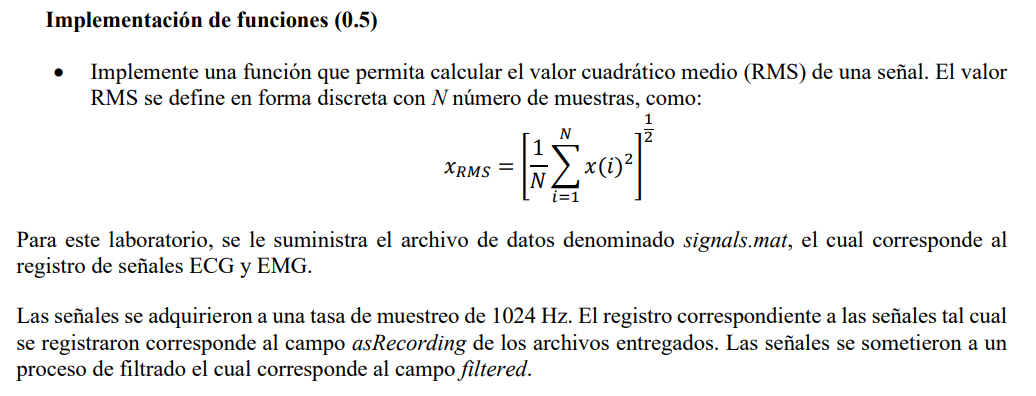 



In [127]:
from scipy.io import loadmat
from statsmodels.tsa.stattools import adfuller
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

In [161]:

data = loadmat("signals.mat")

def calcular_rms(x):
    N = len(x) #número de mmuestras 
    suma = np.sum (x**2)
    xrms = np.sqrt (suma/N)
    return xrms

In [163]:
print (data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'ECG_asRecording', 'ECG_filtered', 'EMG_filtered1', 'EMG_filtered2', 'EMG_asRecording1', 'EMG_asRecording2'])


In [159]:
ecg = data['ECG_asRecording'].flatten()

rms_ecg = calcular_rms(ecg)

print("El Valor Cuadrático Medio (RMS) de los datos ECG es:", rms_ecg)

El Valor Cuadrático Medio (RMS) de los datos ECG es: 4392.9682937490725


# Análisis estadístico de ECG (2.0)

1. A partir de la información suministrada en el archivo .mat, determine el tiempo de duración de las señales, cree un vector de tiempo

In [22]:
ecg_filt = data['ECG_filtered'].flatten()
Fs = int(data['Fs'][0][0])

N = len(ecg)

t = np.arange(N) / Fs

duracion = N / Fs

print("Duración de la señal:", duracion, "segundos")

Duración de la señal: 30.0 segundos


2. Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG

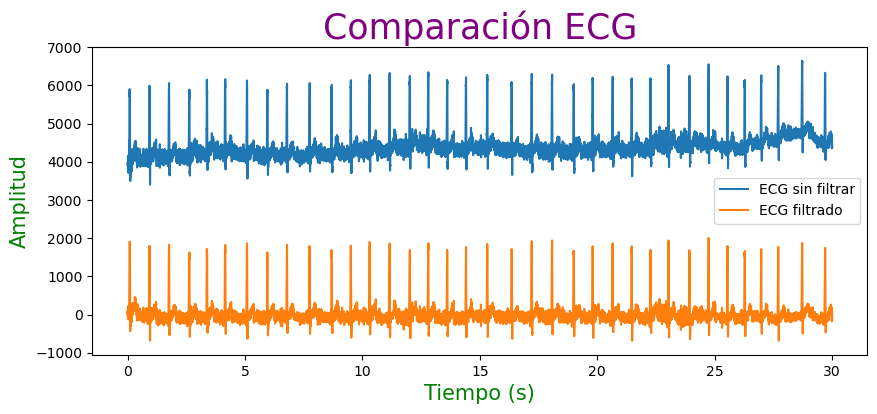

In [64]:
plt.figure(figsize=(10,4))
plt.plot(t, ecg, label='ECG sin filtrar')
plt.plot(t, ecg_filt, label='ECG filtrado')
plt.xlabel('Tiempo (s)', size = "15", color = "green")
plt.ylabel('Amplitud',size = "15", color = "green")
plt.title('Comparación ECG',size = "25", color = "purple")
plt.legend()
plt.show()

3. Tome la señal tal cual se registró. De dicha señal, seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.

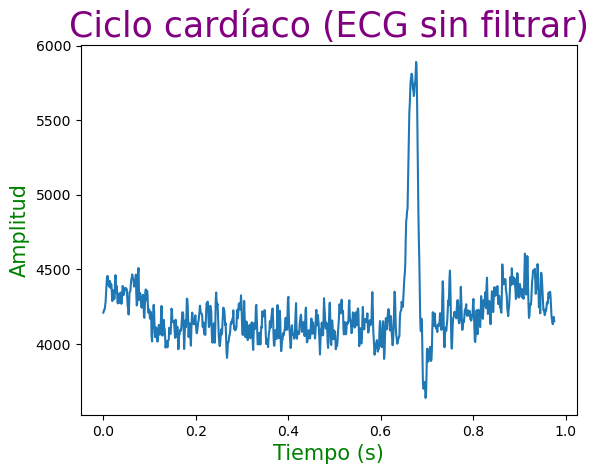

El Promedio de la señar filtrada es: 4217.937852783203
El valor cuadrático medio (RMS) es: 4226.240122425974
La Varianza es: 70105.84246172542
La Desviación estándar es: 264.7750790042851


In [18]:
ciclo = ecg[2000:3000]

t_ciclo = np.arange(len(ciclo)) / Fs
promedio = np.mean(ciclo)
rms = calcular_rms(ciclo)
varianza = np.var(ciclo)
desv = np.std(ciclo)

plt.plot(t_ciclo, ciclo)
plt.title("Ciclo cardíaco (ECG sin filtrar)",size = "25", color = "purple")
plt.xlabel("Tiempo (s)", size = "15", color = "green")
plt.ylabel("Amplitud", size = "15", color = "green")
plt.show()


print("El Promedio de la señar filtrada es:", promedio)
print("El valor cuadrático medio (RMS) es:", rms)
print("La Varianza es:", varianza)
print("La Desviación estándar es:", desv)

4. Tome la señal filtrada. Repita el procedimiento anterior con esta señal, compare con los resultados 
obtenidos en el ítem anterior. 

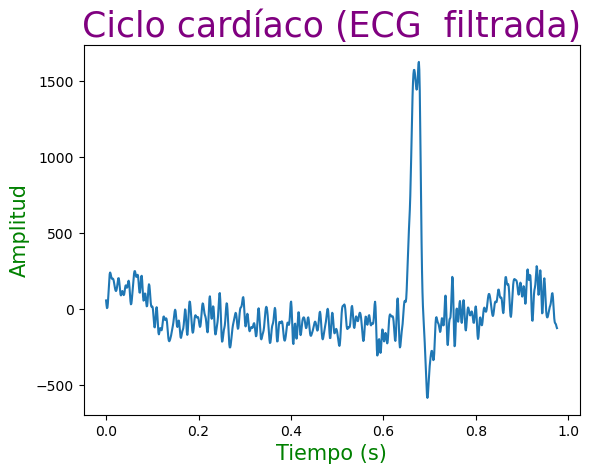

El Promedio de la señal filtrada es: -4.937350266906564
RMS: 258.6333480021569
La Varianza de la señal filtrada: 66866.83127114667
La Desviación estándar de la señal filtrada es: 258.5862163208756


In [20]:
ciclo = ecg_filt [2000:3000]

t_ciclo = np.arange(len(ciclo)) / Fs
promedio = np.mean(ciclo)
rms = calcular_rms(ciclo)
varianza = np.var(ciclo)
desv = np.std(ciclo)

plt.plot(t_ciclo, ciclo)
plt.title("Ciclo cardíaco (ECG  filtrada)", size = "25", color = "purple")
plt.xlabel("Tiempo (s)",size = "15", color = "green")
plt.ylabel("Amplitud",size = "15", color = "green")
plt.show()


print("El Promedio de la señal filtrada es:", promedio)
print("RMS:", rms)
print("La Varianza de la señal filtrada:", varianza)
print("La Desviación estándar de la señal filtrada es:", desv)

5. Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique 
cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?

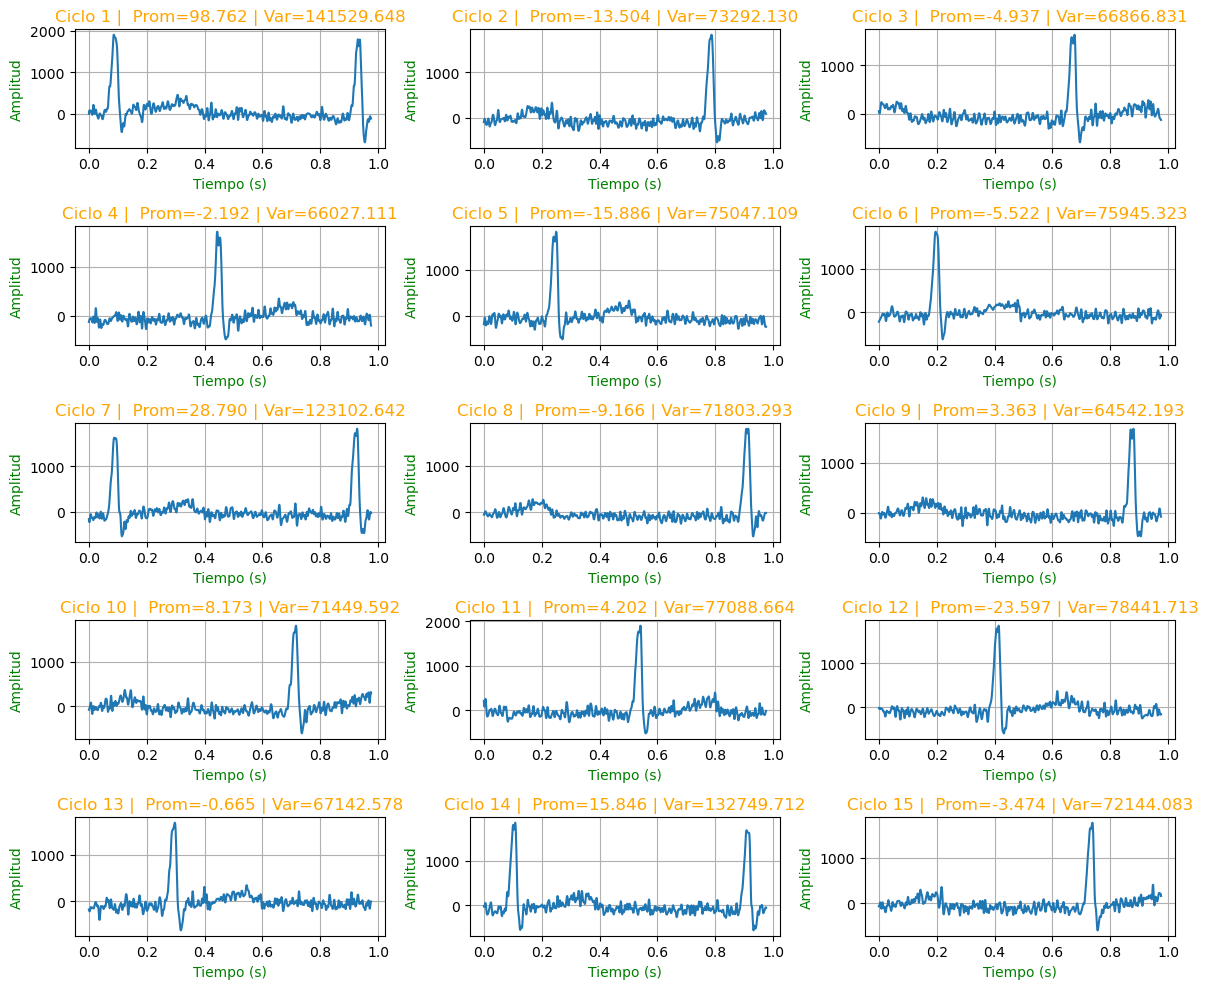

In [49]:
plt.figure(figsize=(12,10))

for i in range(num_ciclos):
    
    inicio = i * L
    fin = inicio + L
    ciclo = ecg_filt[inicio:fin]
    
    t_ciclo = np.arange(len(ciclo)) / Fs
    

    promedio = np.mean(ciclo)
    varianza = np.var(ciclo)
    
    promedios.append(promedio)
    varianzas.append(varianza)
    
    plt.subplot(5, 3, i+1)  # 5 filas x 3 columnas
    plt.plot(t_ciclo, ciclo)
    plt.title(f"Ciclo {i+1} |  Prom={promedio:.3f} | Var={varianza:.3f}", color = "orange")
    plt.xlabel("Tiempo (s)", color = "green")
    plt.ylabel("Amplitud", color = "green")
    plt.grid()

plt.tight_layout()
plt.show()

A partir de la visualización de los ciclos del ECG analizados, se observa que, aunque la forma general de la señal se mantiene, existen variaciones en la amplitud, el nivel medio y la dispersión de los datos entre ciclos. Esto se evidencia en los cambios en los valores promedio y la varianza, los cuales no permanecen constantes.

6. Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine
estadísticamente si existe diferencia estadística entre los ciclos, Compruebe los supuestos necesarios
para realizar una prueba t, esto es: Normalidad de la variable, independencia (se asume que los grupos
son independientes), y homocedasticidad (use una prueba de Levene), finalmente realice la prueba t
para determinar si existen diferencias entre los ciclos. Qué indica este análisis respecto de la
estacionariedad, explique. De no cumplirse los requisitos, realice entonces un análisis no paramétrico
(prueba U de Mann-Whitney).


In [97]:
L = 1000

ciclo1 = ecg_filt[0:L]
ciclo2 = ecg_filt[4*L:5*L]

#Para verificar la normalidad de los datos:
shapiro1 = stats.shapiro(ciclo1)
shapiro2 = stats.shapiro(ciclo2)

print(f"pvalue > 0.05 → distribución normal\npvalue ≤ 0.05 → no normal")
print("Shapiro ciclo1:", shapiro1)
print("Shapiro ciclo2:", shapiro2)


pvalue > 0.05 → distribución normal
pvalue ≤ 0.05 → no normal
Shapiro ciclo1: ShapiroResult(statistic=0.6482335889828293, pvalue=4.0830803216122737e-41)
Shapiro ciclo2: ShapiroResult(statistic=0.5345482514342638, pvalue=2.855655735798511e-45)


In [117]:
#Para verificar Homocedasticidad:
levene_test = stats.levene(ciclo1, ciclo2)
print(f"pvalue  > 0.05 → varianzas iguales \npvalue ≤ 0.05 → varianzas diferentes")
print("Levene:", levene_test)

pvalue  > 0.05 → varianzas iguales 
pvalue ≤ 0.05 → varianzas diferentes
Levene: LeveneResult(statistic=30.567699896644886, pvalue=3.6469971967703493e-08)


# Como no se cumple el supuesto de normalidad, no podemos aplicar la prueba t de student pero usaremos la prueba

In [119]:
#Aplicamos la prueba Mann-Whitney U
mw1 = stats.mannwhitneyu(ciclo1, ciclo2)
print(mw1)

MannwhitneyuResult(statistic=654824.0, pvalue=4.0294438077589675e-33)


Los resultados de la prueba t muestran valores de p mayores a 0.05, lo que indica que no existen diferencias estadísticamente significativas entre los ciclos analizados. Esto sugiere que la señal mantiene propiedades estadísticas constantes en el tiempo, por lo que puede considerarse aproximadamente estacionaria.

In [99]:
ciclo3 = ecg_filt[1*L:2*L]
ciclo4 = ecg_filt[9*L:10*L]

#Para verificar la normalidad de los datos:
shapiro3 = stats.shapiro(ciclo3)
shapiro4 = stats.shapiro(ciclo4)

print(f"pvalue > 0.05 → distribución normal\np ≤ 0.05 → no normal")
print("Shapiro ciclo3:", shapiro3)
print("Shapiro ciclo4:", shapiro4)


pvalue > 0.05 → distribución normal
p ≤ 0.05 → no normal
Shapiro ciclo3: ShapiroResult(statistic=0.5547511668808043, pvalue=1.3427795864570213e-44)
Shapiro ciclo4: ShapiroResult(statistic=0.61367359060601, pvalue=1.7521153834827494e-42)


In [104]:
#Para verificar Homocedasticidad:
levene_test2 = stats.levene(ciclo3, ciclo4)
print(f"pvalue  > 0.05 → varianzas iguales \npvalue ≤ 0.05 → varianzas diferentes")
print("Levene:", levene_test2)

pvalue  > 0.05 → varianzas iguales 
pvalue ≤ 0.05 → varianzas diferentes
Levene: LeveneResult(statistic=1.099713270858184, pvalue=0.2944558699117547)


# Como no se cumple el supuesto de normalidad, no podemos aplicar la prueba t de student pero usaremos la prueba

In [113]:
#Aplicamos la prueba Mann-Whitney U
mw2 = stats.mannwhitneyu(ciclo3, ciclo4)
print(mw2)

MannwhitneyuResult(statistic=457885.0, pvalue=0.00110879207888733)


La prueba de normalidad de Shapiro-Wilk indicó que los datos no siguen una distribución normal (p < 0.05). Sin embargo, la prueba de Levene mostró que las varianzas son homogéneas (p > 0.05).

Debido a que no se cumple el supuesto de normalidad, la aplicación de la prueba t de Student no es completamente válida. Por lo tanto, aplicamos  una prueba no paramétrica como la prueba U de Mann-Whitney para comparar los ciclos.

Los resultados de la prueba no paramétrica de Mann-Whitney muestran valores de p muy inferiores a 0.05 en ambas comparaciones realizadas (ciclo 1 vs ciclo 2 y ciclo 3 vs ciclo 4), lo que indica diferencias estadísticamente significativas entre los ciclos analizados.
Esto evidencia que las propiedades estadísticas de la señal no permanecen constantes en el tiempo. Por lo tanto, se concluye que la señal no es estacionaria en el intervalo estudiado.

En este caso, al tratarse de un ECG esto puede significar:
- Variabilidad fisiológica (ritmo cardíaco)
- Ruido o artefactos
- Cambios en la morfología del latido

7. Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad) 

Usando la prueba de Dickey-Fuller se plantea:
H₀ - Hipótesis Nula: la señal No es estacionaria
H₁: la señal Sí es estacionaria

In [137]:
resultado = adfuller(ecg_filt)

print("Estadístico ADF:", resultado[0])
print("p-value:", resultado[1])


Estadístico ADF: -13.118409718332577
p-value: 1.5815306408065834e-24


La prueba de Dickey-Fuller aumentada arrojó un p-value muy inferior a 0.05, lo que permite rechazar la hipótesis nula y concluir que la señal es estacionaria en sentido global. Sin embargo, los análisis previos mediante la prueba de Mann-Whitney U evidenciaron diferencias significativas entre algunos ciclos, lo que indica la presencia de variaciones locales en la señal. Por lo tanto, se puede concluir que la señal es globalmente estacionaria, pero presenta variaciones locales que pueden deberse a características fisiológicas propias del ECG o a ruido en la señal.

# Análisis y Conclusiones
Se realizó el análisis estadístico y temporal de la señal de ECG filtrada, considerando tanto su comportamiento global como local mediante la segmentación en ciclos.

En primer lugar, se extrajeron múltiples ciclos de la señal y se analizaron individualmente. A partir de la visualización gráfica, se observó que todos los ciclos conservan una morfología característica del ECG, haciendo evidente la presencia del complejo QRS. Sin embargo, se evidencian variaciones en la amplitud, en la posición temporal de los picos y en el nivel base de la señal. Estas diferencias sugieren la presencia de variabilidad entre ciclos.

Desde el punto de vista estadístico, se calcularon parámetros como el promedio y la varianza para cada ciclo. Los resultados muestran que dichos valores no permanecen constantes, evidenciando cambios significativos entre segmentos de la señal. Esto indica que la señal no cumple estrictamente con las condiciones de estacionariedad en sentido débil.

Posteriormente, se aplicaron pruebas estadísticas para comparar ciclos:

La prueba de normalidad de Shapiro-Wilk indicó que los datos no siguen una distribución normal.
La prueba de Levene confirmó homogeneidad de varianzas entre ciclos.
Debido a la falta de normalidad, se utilizó la prueba no paramétrica de Mann-Whitney, la cual evidenció diferencias estadísticamente significativas entre varios pares de ciclos.

Finalmente, se aplicó la prueba de Dickey-Fuller aumentada (ADF) para evaluar la estacionariedad global de la señal. El resultado arrojó un p-value significativamente menor a 0.05, lo que permite rechazar la hipótesis nula de no estacionariedad, indicando que la señal es estacionaria en un sentido global.

- La señal de ECG presenta una morfología consistente entre ciclos, lo que indica estabilidad en el tiempo. Sin embargo, los parámetros estadísticos como la media y la varianza varían entre ciclos, lo que evidencia que la señal no es estrictamente estacionaria en sentido local.
- Las pruebas estadísticas (Mann-Whitney) confirmaron la existencia de diferencias significativas entre ciclos, reforzando la idea de variabilidad temporal.
- La prueba de Dickey-Fuller indicó que la señal es estacionaria en sentido global, lo que sugiere la ausencia de tendencias o componentes no estacionarios dominantes.
- En conjunto, se concluye que la señal de ECG es casiestacionaria, es decir, presenta estacionariedad global pero con variaciones locales, lo cual es característico de señales fisiológicas reales. Este comportamiento puede deberse a factores fisiológicos como la variabilidad del ritmo cardíaco o a posibles fuentes de ruido e interferencias en la adquisición de la señal.

# Referencias 
Proakis, J. G., & Manolakis, D. G. (2007). Digital signal processing: Principles, algorithms, and applications (4th ed.). Pearson

Rangayyan, R. M. (2015). Biomedical signal analysis: A case-study approach (2nd ed.). Wiley-IEEE Press.

NumPy Documentation: https://numpy.org

SciPy Documentation: https://scipy.org

Statsmodels Documentation: https://www.statsmodels.org

